In [ ]:
x = 5
y = 7

live demo code


In [ ]:
import folium

In [ ]:
#pip install folium

In [ ]:
latitude = 43.703
longitude = -72.288

In [ ]:
map = folium.Map(location=[latitude, longitude], zoom_start=12)

In [ ]:
map

In [ ]:
# importing a few more libraries
# plotting
import matplotlib.pyplot as plt
# data wrangling
import pandas as pd
# geospatial data wrangling & geometric analysis
import geopandas as gpd
# working with shapes and spatial objects
import shapely

In [ ]:
points_csv = pd.read_csv("https://rcweb.dartmouth.edu/homes/f002d69/workshops/data/bear-sightings.csv")

In [ ]:
points_csv.head(3)

,bear.id,longitude,latitude
0,7,-148.956023,62.658220
1,57,-152.622839,58.350642
2,69,-144.937397,62.382270


In [ ]:
# Specify the path to your .shp file
shapefile_path = "https://rcweb.dartmouth.edu/homes/f002d69/workshops/data/nationalparks_ak.zip"

# Read the shapefile into a GeoDataFrame
polygons_gdf = gpd.read_file(shapefile_path)

In [ ]:
polygons_gdf.head(3)

,Unit_Code,Unit_Name,Unit_Type,NPS_Region,ScaleRank,FeatureCla,Note,Name,geometry
0,YUCH,Yukon-Charley Rivers N PRES,National Preserve,Alaska,4,National Park Service,None,Yukon-Charley Rivers N PRES,"POLYGON ((-142.34907 64.99516, -142.34907 64.9..."
1,NOAT,Noatak N PRES,National Preserve,Alaska,4,National Park Service,None,Noatak N PRES,"POLYGON ((-155.65266 68.02284, -155.65266 68.0..."
2,KOVA,Kobuk Valley NP,National Park,Alaska,4,National Park Service,None,Kobuk Valley,"POLYGON ((-157.85947 67.42408, -157.85947 67.4..."


In [ ]:
points_gdf = gpd.GeoDataFrame(points_csv, geometry=gpd.points_from_xy(points_csv.longitude, points_csv.latitude))

In [ ]:
points_gdf.head(3)

,bear.id,longitude,latitude,geometry
0,7,-148.956023,62.658220,POINT (-148.95602 62.65822)
1,57,-152.622839,58.350642,POINT (-152.62284 58.35064)
2,69,-144.937397,62.382270,POINT (-144.9374 62.38227)


In [ ]:
points_gdf.crs= 'EPSG:4326' # https://epsg.io/4326

In [ ]:
points_gdf = points_gdf.to_crs(polygons_gdf.crs)

In [ ]:
points_in_polygons = gpd.sjoin(points_gdf, polygons_gdf, how="inner", predicate="within")
points_in_polygons.head(3)

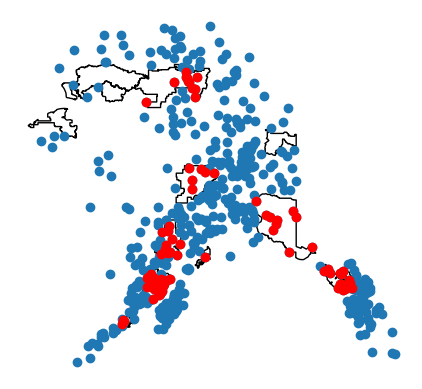

In [ ]:
# make a map here:
polygons_gdf.plot(facecolor='none')
points_gdf.plot(ax=plt.gca())
points_in_polygons.plot(color='red', ax=plt.gca())
plt.axis("off")
plt.show()

In [ ]:
mid_lat = polygons_gdf.geometry.centroid.y.mean()
mid_lon = polygons_gdf.geometry.centroid.x.mean()
map_folium = folium.Map(location=[mid_lat, mid_lon], zoom_start=5)
for idx, row in polygons_gdf.iterrows():
    # Ensure geometry is a Polygon or MultiPolygon
    geom = row.geometry
    if geom.geom_type == 'Polygon':
        coords = [(y, x) for x, y in geom.exterior.coords]
        folium.Polygon(
            locations=coords,
            fill=True,
            popup=f"Polygon: {row['Unit_Name']}"
        ).add_to(map_folium)
    elif geom.geom_type == 'MultiPolygon':
        # If multipolygon, add each polygon separately
        for poly in geom.geoms:
            coords = [(y, x) for x, y in poly.exterior.coords]
            folium.Polygon(
                locations=coords,
                fill=True,
                popup=f"Polygon: {row['Unit_Name']}"
            ).add_to(map_folium)

            # plot all of the bear sightings...
# Iterate over the rows of your GeoDataFrame
for index, row in points_gdf.iterrows():
    # Get the coordinates of the point
    lat = row.geometry.y
    lon = row.geometry.x

    # Add a marker to the map
    folium.Marker([lat, lon], popup=row['bear.id']).add_to(map_folium) # Assuming you have a 'name' column for popups

map_folium

# Display the folium map (outside the loop)
map_folium

# To clear the map, re-initialize it
#my_map = folium.Map(location=[40.7128, -74.0060], zoom_start=9)
map_folium #Display the cleared map

/tmp/ipython-input-330132707.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mid_lat = polygons_gdf.geometry.centroid.y.mean()
/tmp/ipython-input-330132707.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mid_lon = polygons_gdf.geometry.centroid.x.mean()


In [ ]:
# next, plot the bears inside polygons, using red icons ,

#popup_text = f"{row['bear.id']} {row['Unit_Name']}"

for index, row in points_in_polygons.iterrows():
    # Get the coordinates of the point
    lat = row.geometry.y
    lon = row.geometry.x

    # Add a marker to the map
    folium.Marker([lat, lon], icon=folium.Icon(color="red"), popup=f"Bear ID: {row['bear.id']}, Park: {row['Unit_Name']}", color='red').add_to(map_folium) # Assuming you have a 'name' column for popups
#             icon=folium.Icon(color="red"),

map_folium